# Python Basis for Neuroengineering

### Tutors: 
- Francesco De Santis (francesco.desantis@polimi.it)
- Alessia Zannino (alessia.zannino@polimi.it)


## Learning objectives
Welcome!

In this notebook we will learn the basic Python tools needed to work with scientific and neuroengineering data. By the end of this notebook, you should be able to:

- work with basic Python data types;
- use conditions and loops;
- Use constructs like list/dict comprehensions and dynamic functions (`*args`, `**kwargs`).
- Manipulate data with **NumPy** arrays and broadcasting;
- Process signals using **SciPy**;
- Organize experimental metrics into **Pandas** DataFrames for batch analysis and export.
- Design plots with **Matplotlib**;


**You do not need to memorize Python syntax.**

Focus on understanding what the code does and how to modify it.

## What is Python?

Python is a general-purpose programming language that is widely used in science and engineering.

In this course, we will use Python to:

- work with experimental data;
- perform numerical calculations;
- visualize signals;
- implement simple analyses;
- build reproducible analysis workflows.

## 1. Variables and data types

Python can work with different types of data, including:

- Integers (`int`)
- Floating-point numbers (`float`)
- Text (`str`)
- Boolean values (`bool`)

In Python, we don't need to declare the variables. The data type of a variable is determined during the execution.

In [1]:
sampling_rate = 2000          # int (Hz)
duration = 5.0                # float (s)
muscle = "Tibialis Anterior"  # str
is_rectified = False          # bool

print(f"Recording EMG from {muscle} for {duration} s at {sampling_rate} Hz.")

Recording EMG from Tibialis Anterior for 5.0 s at 2000 Hz.


This is called dynamic typing:

In [2]:
duration = 5.0
print(type(duration))

<class 'float'>


In [3]:
duration = 5
print(type(duration))

<class 'int'>


## 2. Lists

A list is an ordered collection of values enclosed in square brackets [ ].

- It can store elements of different data types in the same list (e.g., text, numbers, booleans).
- It is a dynamic object (mutable), meaning you can add, remove, or modify elements after creation, unlike a Tuple, enclosed in round brackets ( ), which is fixed (immutable).

For example, we can store the names of different muscles in a list:

- TA = tibialis anterior
- MG = medial gastrocnemius
- LG = lateral gastrocnemius
- RF = rectus femoris

In [4]:
muscles = ["TA","MG","LG","RF"]
print(muscles)

['TA', 'MG', 'LG', 'RF']


In [5]:
muscles.append("BF")
print(muscles)

['TA', 'MG', 'LG', 'RF', 'BF']


### Exercise 2.1 — Selecting muscles

Now, given the list, we want to find:

1) the first muscle;
2) the last muscle;
3) the third muscle;
4) the first two muscles;
5) the second and third muscles;

In [6]:
# 1. First muscle (index 0)
print("First muscle:", muscles[0])

# 2. Last muscle (negative index)
print("Last muscle:", muscles[-1])

# 3. Third muscle (remember 0-based indexing)
print("Third muscle:", muscles[2])

# 4. First two muscles (slicing: from start up to index 2, excluded)
print("First two muscles:", muscles[:2])

# 5. Second and third muscles (slicing: from index 1 up to index 3, excluded)
print("Second and third muscles:", muscles[1:3])

First muscle: TA
Last muscle: BF
Third muscle: LG
First two muscles: ['TA', 'MG']
Second and third muscles: ['MG', 'LG']


## 3. Dictionaries
A dictionary is an unordered, mutable data structure containing key-value pairs, where each value is uniquely identified by its key (rather than an integer index like in lists).

- Keys must be unique and immutable (usually strings or numbers)
- Values can be of any data type, including numbers, strings, lists, or even other dictionaries
- Enclosed in curly brackets { } with key-value pairs separated by colons `:`

For example, we can store metadata for a specific trial:

In [7]:
trial = {
    "subject": "sub-01", "muscle": "TA", "stimulation_frequency": 30,
    "stimulation_amplitude": 20, "pulse_width": 300, "condition": "FES"
}

### Exercise 3.1 — Adding elements to a dictionary

Add the following information to the trial:

- EMG sampling rate: 2000 Hz
- stimulation duration: 5 seconds
- electrode configuration: `"surface"`

In [8]:
trial["sampling_rate"] = 2000
trial["stimulation_duration"] = 5
trial["electrode_configuration"] = "surface"

In [9]:
print(trial)

{'subject': 'sub-01', 'muscle': 'TA', 'stimulation_frequency': 30, 'stimulation_amplitude': 20, 'pulse_width': 300, 'condition': 'FES', 'sampling_rate': 2000, 'stimulation_duration': 5, 'electrode_configuration': 'surface'}


In [10]:
print(trial["sampling_rate"])

2000


## 4. Control Flow: Conditions (`if`, `elif`, `else`)
Pay attention to the syntax: conditional statements must end with a colon `:` and use indentation for the code block.

In [11]:
stimulation_amplitude = 25  # mA
threshold = 20              # mA

if stimulation_amplitude > threshold:
    print("High stimulation amplitude applied.")
elif stimulation_amplitude == threshold:
    print("Stimulation amplitude is exactly at threshold.")
else:
    print("Low stimulation amplitude applied.")

High stimulation amplitude applied.


## 5. Iteration: For and While Loops

### Exercise 5.1 - Iterating over list elements
We have a list of channels, some for EMG acquisition (starting with "EMG") and one for functional electrical stimulation (starting with "FES"). We want to print the EMG channels. 


In [12]:
# FOR LOOP: 
channels = ["EMG_TA", "EMG_MG", "EMG_RF", "FES_STIM"]

print("--- Scanning Channels ---")
for channel in channels: #channel is a temporary variable
    if channel.startswith("EMG"): #startswith is a method for phyton strings
        print(f"Processing muscle channel: {channel}")
    else:
        print(f"Skipping auxiliary channel: {channel}")

--- Scanning Channels ---
Processing muscle channel: EMG_TA
Processing muscle channel: EMG_MG
Processing muscle channel: EMG_RF
Skipping auxiliary channel: FES_STIM


### Exercise 5.2 - Iterating until a specific condition is met
We want to increase the FES stimulation current within safety limits...

In [13]:
# WHILE LOOP: 
print("\n--- FES Stimulation Ramp ---")

current_mA = 2.0          # Starting stimulation current (mA)
pain_threshold_mA = 25.0  # Patient pain/tolerance threshold (mA)
step_size_mA = 4.0        # Current increment step (mA)
step = 0

# Ramp up stimulation current as long as it remains strictly below the pain threshold
while current_mA + step_size_mA <= pain_threshold_mA:
    step += 1
    current_mA += step_size_mA
    print(f"Step {step}: Delivering current at {current_mA:.1f} mA (Safe)")

print(f"SAFETY LIMIT: Next step would reach or exceed pain threshold ({pain_threshold_mA:.1f} mA). Stop.")


--- FES Stimulation Ramp ---
Step 1: Delivering current at 6.0 mA (Safe)
Step 2: Delivering current at 10.0 mA (Safe)
Step 3: Delivering current at 14.0 mA (Safe)
Step 4: Delivering current at 18.0 mA (Safe)
Step 5: Delivering current at 22.0 mA (Safe)
SAFETY LIMIT: Next step would reach or exceed pain threshold (25.0 mA). Stop.


## 6. Writing Pythonic Code: List & Dict Comprehensions

"Pythonic" code uses native idioms to write with efficient logic.
**List and Dict Comprehensions** allow you to replace multiple lines of code with a few lines. 

Look at the following approaches while working with lists.

In [14]:
channels = ["EMG_TA", "EMG_MG", "EMG_RF", "FES_STIM"]

# Approach A: Non-Pythonic (C/MATLAB style)

emg_channels_A = [] #Empty list initialization
for ch in channels:
    if ch.startswith("EMG"):
        emg_channels_A.append(ch) # Method: append matching channel to the end of the list
print("Extracted EMG channels:", emg_channels_A)


Extracted EMG channels: ['EMG_TA', 'EMG_MG', 'EMG_RF']


In [15]:
# Approach B: Pythonic style (List Comprehension)
emg_channels_B = [ch for ch in channels if ch.startswith("EMG")]
print("Extracted EMG channels:", emg_channels_B)


Extracted EMG channels: ['EMG_TA', 'EMG_MG', 'EMG_RF']


### Exercise 6.1 - Dict Comprehension
For each of three subjects, we have the RMS amplitude of the EMG signal measured for a specific muscle over a given time-window. We want to classify whether the muscle was contracted ("Active") or relaxed ("Inactive") based on a threshold.

In [16]:
# RMS values (in mV) calculated over a 500 ms time-window for the TA muscle
subject_rms = {"sub-01": 0.42, "sub-02": 0.18, "sub-03": 0.55}

# Threshold for muscle contraction classification (in mV)
THRESHOLD = 0.3

# Approach A: Non-Pythonic (Explicit loop over dictionary)
status_a = {}
for sub, rms in subject_rms.items(): #The .items() method unpacks the dictionary into key-value pairs
    if rms > THRESHOLD:
        status_a[sub] = "Active"
    else:
        status_a[sub] = "Inactive"
print("Subject Status (Loop):", status_a)


# Approach B: Pythonic style (Dict Comprehension with Ternary Operator)
status_b = {sub: ("Active" if rms > THRESHOLD else "Inactive") for sub, rms in subject_rms.items()} #we are creating a new dictionary
print("Subject Status (Dict Comprehension):", status_b)


Subject Status (Loop): {'sub-01': 'Active', 'sub-02': 'Inactive', 'sub-03': 'Active'}
Subject Status (Dict Comprehension): {'sub-01': 'Active', 'sub-02': 'Inactive', 'sub-03': 'Active'}


## 7. Functions

Functions are reusable blocks of code with inputs and returns; the are preceded by the `def` keyword. As an example, we write a function to calculate the RMS of a signal. 

In [17]:
import math

#we define the function "calculate_rms" which takes signal_list as input
def calculate_rms(signal_list):    
    """Calculates the Root Mean Square (RMS) of a list of biosignal values.""" # this is a Docstring, a kind of public documentation, try to type help(calculate_rms)
    squares = [x**2 for x in signal_list]
    mean_square = sum(squares) / len(signal_list)
    return math.sqrt(mean_square)

# Test the basic function
emg_channel_1 = [0.15, -0.32, 0.45, -0.12, 0.28]
rms_ch1 = calculate_rms(emg_channel_1)
print(f"RMS Channel 1: {rms_ch1:.3f} mV") # Format the result to 3 decimal places

RMS Channel 1: 0.290 mV


### 7.1 Introduction to *args (Variable Positional Arguments)
Standard functions expect a fixed number of arguments; `*args` allows us to pass a variable number of positional arguments to a function. The single asterisk (`*`) acts as an automatic "packer". It collects all loose individual arguments passed by the user into a single **Tuple** (`args`). Once created, this tuple contains all passed values in a secure, read-only format.

In [18]:
def calculate_average(*args):    
    # Safety check: avoid division by zero if no arguments are passed
    if len(args) == 0:
        return 0.0
    
    return sum(args) / len(args)


# --- Testing the function ---
rms_ch1 = 0.291
rms_ch2 = 0.520
rms_ch3 = 0.180
rms_ch4 = 0.610

# We pass the previously computed RMS values to calculate their mean across channels
avg_rms_4ch = calculate_average(rms_ch1, rms_ch2, rms_ch3, rms_ch4)
print(f"Average RMS across 4 channels: {avg_rms_4ch:.3f} mV")

avg_rms_3ch = calculate_average(rms_ch1, rms_ch2, rms_ch3)
print(f"Average RMS across 3 channels: {avg_rms_3ch:.3f} mV")

Average RMS across 4 channels: 0.400 mV
Average RMS across 3 channels: 0.330 mV


### 7.2 Advanced Function Flexibility: `**kwargs` (Keyword Arguments)

While `*args` handles variable positional values, `**kwargs` syntax allows a function to accept **any number of named arguments (`key=value`)**.

The double asterisk (`**`) acts as a keyword collector. It automatically packs all named arguments passed by the user into a standard **Dictionary** (`kwargs`), where parameters become dictionary keys and their values become dictionary values.

In [19]:
#EXAMPLE: Calculate the mean of a list of numbers with optional rounding.

def calculate_mean(numbers, **kwargs):
    mean_value = sum(numbers) / len(numbers)

    # 2. Extract the optional rounding preference using .get();
    #    If the user doesn't specify 'decimals', default is 4
    decimals = kwargs.get("decimals", 4)

    return round(mean_value, decimals)



### Exercise 7.2.1 Basic call (No optional arguments)

In [20]:
data = [1.252, 2.832, 3.172, 4.514]

mean_exact = calculate_mean(data)
print(f"Exact Mean: {mean_exact}") 
# Output will have 4 decimals (default we set) because no further parameters were given

Exact Mean: 2.9425


### Exercise 7.2.2: Use **kwargs

In [21]:
 
mean_rounded = calculate_mean(data, decimals=2)
print(f"Rounded Mean: {mean_rounded}")


Rounded Mean: 2.94


Now look at this:

In [22]:
mean_rounded = calculate_mean(data, decimals=2, scale=3)
print(f"Rounded Mean: {mean_rounded}")

Rounded Mean: 2.94


No errors, even if scale is not used in the function!

## 8. File I/O

Experimental data are usually stored in files rather than directly in the Python code.

Common formats include:

- CSV (`.csv`) — tabular data;
- TXT (`.txt`) — plain text files;
- JSON (`.json`) — structured data and metadata;
- Excel (`.xlsx`) — spreadsheet data.

Python provides built-in tools for reading and writing files.

However, for tabular experimental data we usually use **Pandas**, which provides convenient functions for loading, inspecting, and exporting datasets.


### 8.1 Reading and writing text files

The built-in `open()` function can be used to read and write files. The `with` statement is commonly used because it automatically closes the file after the operation is completed.


In [23]:
# Create a simple text file

with open("experiment_info.txt", "w") as file: 
    # "w" means write; you can also have "r" to read and "a" to append
    file.write("Subject: sub-01\n")
    file.write("Acquisition: EMG\n")
    file.write("Sampling rate: 2000 Hz\n")


In [24]:
with open("experiment_info.txt", "r") as file:
    content = file.read()

print(content)


Subject: sub-01
Acquisition: EMG
Sampling rate: 2000 Hz



## 9. Pandas

**Pandas** is a Python library designed for working with structured and tabular data. Its main data structure is the **DataFrame**, which can be thought of as a table containing rows and columns.


In [25]:
import pandas as pd


### 9.1 Creating a DataFrame

A DataFrame can be created from a Python dictionary. For example, suppose we have measured the RMS amplitude of the tibialis anterior muscle in three subjects (during FES for two subjects).


In [26]:
data = {
    "subject": ["sub-01", "sub-02", "sub-03"],
    "muscle": ["TA", "TA", "TA"],
    "condition": ["Stimulation", "Stimulation", "Control"],
    "rms": [0.42, 0.18, 0.31]
}

df = pd.DataFrame(data)

print(df)


  subject muscle    condition   rms
0  sub-01     TA  Stimulation  0.42
1  sub-02     TA  Stimulation  0.18
2  sub-03     TA      Control  0.31


We can access colums with their names and also perform basic calculations directly on a column.


In [27]:
print(df["subject"])
print(df["rms"])

0    sub-01
1    sub-02
2    sub-03
Name: subject, dtype: str
0    0.42
1    0.18
2    0.31
Name: rms, dtype: float64


In [28]:
print("Mean RMS:", df["rms"].mean())
print("Maximum RMS:", df["rms"].max())
print("Minimum RMS:", df["rms"].min())

Mean RMS: 0.3033333333333333
Maximum RMS: 0.42
Minimum RMS: 0.18


### 9.2 Reading a CSV file

In real experiments, the DataFrame will usually be created by loading data from a file.

The `read_csv()` function reads a CSV file and returns a DataFrame

In [29]:
df = pd.read_csv("emg_trials.csv")

print(df)


FileNotFoundError: [Errno 2] No such file or directory: 'emg_trials.csv'

Before starting an analysis it is good practice to inspect the structure of an unfamiliar dataset. Some useful commands are:

In [38]:
print(df.head()) #displays the first rows of the DataFrame
print(df.shape) #returns the number of rows and columns
print(df.columns) #returns the names of the columns

  subject muscle    condition   rms
0  sub-01     TA  Stimulation  0.42
1  sub-02     TA  Stimulation  0.18
2  sub-03     TA      Control  0.31
(3, 4)
Index(['subject', 'muscle', 'condition', 'rms'], dtype='str')


### 9.3 Selecting and filtering data

Pandas allows us to select observations based on conditions.
For example, we can select only trials performed under the FES condition.


In [39]:
fes_trials = df[df["condition"] == "FES"]

print(fes_trials)


Empty DataFrame
Columns: [subject, muscle, condition, rms]
Index: []


We can also combine multiple conditions.

For example, we can select FES trials where the RMS amplitude is greater than 0.3 mV.


In [40]:
active_fes_trials = df[
    (df["condition"] == "FES") & (df["rms"] > 0.3)
]

print(active_fes_trials)


Empty DataFrame
Columns: [subject, muscle, condition, rms]
Index: []


### 9.4 Saving results

After performing an analysis, we often want to save the results for further analysis or sharing. A DataFrame can be exported to a CSV file using `to_csv()`.


In [41]:
active_fes_trials.to_csv(
    "active_fes_trials.csv",
    index=False #prevents Pandas from adding the DataFrame index as an additional column
)


## 10. Handling Errors

When working with experimental data, errors can occur for many reasons.

For example:

- a file may not exist;
- a value may have the wrong format;
- a column may be missing;
- a user may provide an invalid input.

Python allows us to handle expected errors using `try` and `except`.


For example, when loading experimental data, a common problem is that the requested file does not exist.

In [42]:
filename = "recording.csv"
data = pd.read_csv(filename)

FileNotFoundError: [Errno 2] No such file or directory: 'recording.csv'

Look how we can handle the error:

In [30]:
filename = "recording.csv"

try:
    data = pd.read_csv(filename)
    print("File loaded successfully.")

except FileNotFoundError: #Python built-in exception
    print(f"Could not find the file: {filename}")


Could not find the file: recording.csv


## 11. NumPy

When working with biosignals, we often need to perform mathematical operations on thousands of samples and Python lists become inefficient.

NumPy is a library that provides arrays and N-dimensional array objects that are particularly useful for numerical data and fast vector calculations.


In [31]:
import numpy as np #import numpy and use its functionalities with the np alias

# Create a 1D NumPy array representing raw EMG samples (in mV)
emg = np.array([
    0.12, -0.08, 0.25, -0.31, 0.15
])

print(emg)

[ 0.12 -0.08  0.25 -0.31  0.15]


Look at this difference:

In [32]:
list_emg = [0.12, -0.08, 0.25]
print(list_emg * 2)  
# Standard Python list: multiplying replicates the list elements

array_emg = np.array([0.12, -0.08, 0.25])
print(array_emg * 2)  
# NumPy array: element-wise operations (scalar multiplication)

[0.12, -0.08, 0.25, 0.12, -0.08, 0.25]
[ 0.24 -0.16  0.5 ]


### Exercise 11.1 - Basic EMG statistics

Calculate:

1. the number of samples;
2. the mean EMG amplitude;
3. the maximum amplitude;
4. the minimum amplitude.

In [33]:
print(len(emg))
print(emg.mean())
print(emg.max())
print(emg.min())

5
0.025999999999999995
0.25
-0.31


### Exercise 11.2 - Creating a synthetic EMG signal

Let's create a simplified synthetic EMG signal.

For this example, we will simulate EMG as a combination of oscillatory components and noise.

In [34]:
# 1. Define acquisition parameters
sampling_rate = 2000  # Sampling frequency in Hz (2000 samples/second)
duration = 5           # Signal duration in seconds
num_samples = sampling_rate * duration  # Total number of samples (10,000)

# 2. Create the time vector
# np.linspace(start, stop, num_samples) creates an exact number of evenly spaced points.
# endpoint=False ensures t = 5.0 s is not included, keeping the exact duration count.

time = np.linspace(0, duration, num_samples, endpoint=False)

# 3. Synthesize the raw EMG signal:
emg = (
    0.4 * np.sin(2 * np.pi * 80 * time)       #First sinusoid: 80 Hz component scaled by 0.4
    + 0.2 * np.sin(2 * np.pi * 120 * time)    #Second sinusoid: 120 Hz component scaled by 0.2
    + 0.5 * np.random.randn(len(time))        #Noise: Gaussian random numbers scaled by 0.5 (simulating background noise)
)

# Verify the signal dimensions
print("Signal shape:", emg.shape) #1D array with 10000 elements
print("Total number of samples:", len(emg))
print("First 5 time points (s):", time[:5])

Signal shape: (10000,)
Total number of samples: 10000
First 5 time points (s): [0.     0.0005 0.001  0.0015 0.002 ]


## 12. `scipy.signal`: Signal Processing

**SciPy** (specifically `scipy.signal`) provides dedicated algorithms to filter, analyze, and transform signals.


### Key Concepts for Signal Filtering

1. **Filter Types:**
   - **Butterworth Filter (`scipy.signal.butter`):** Widely used in biomedical applications due to its maximally flat frequency response in the passband (no ripple).
   - **Low-pass:** Attenuates frequencies above a cutoff (e.g., removing high-frequency noise).
   - **High-pass:** Attenuates frequencies below a cutoff (e.g., removing baseline artifacts).
   - **Band-pass:** Retains a specific frequency range (e.g., keeping $20-450\text{ Hz}$ for EMG).

2. **Zero-Phase Filtering (`scipy.signal.filtfilt`):**
   - Standard filtering (`lfilter`) introduces a **phase shift** (time delay) in the output signal.
   - Forward-backward filtering (`filtfilt`) runs the filter twice (forward and backward), completely eliminating phase distortion and preserving peak alignment in time (only offline analyses).

Matplotlib is building the font cache; this may take a moment.


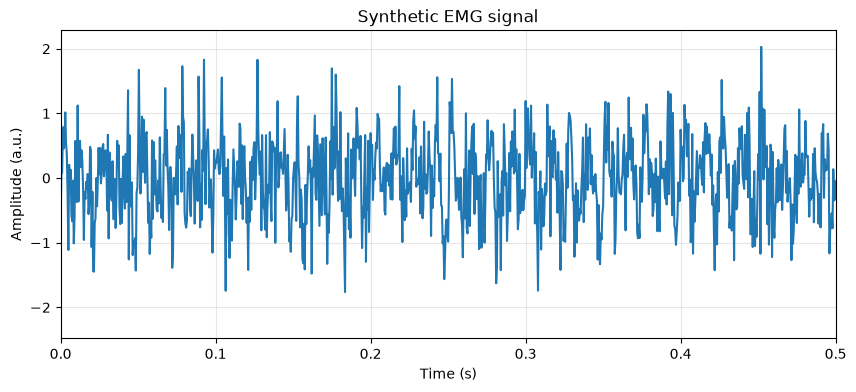

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(time, emg)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Synthetic EMG signal")

# Show only the first 0.5 seconds
plt.xlim(0, 0.5)

plt.grid(alpha=0.3)
plt.show()



In [ ]:
from scipy import signal


low_cutoff = 20      # Lower cutoff frequency (Hz)
high_cutoff = 450    # Upper cutoff frequency (Hz)
filter_order = 4

sos = signal.butter(
    filter_order, 
    [low_cutoff, high_cutoff], 
    btype="bandpass",
    fs=sampling_rate,
    output="sos"
)

emg_filtered = signal.sosfiltfilt(sos, emg)

plt.figure(figsize=(10, 5))

plt.plot(
    time,
    emg,
    label="Raw EMG",
    alpha=0.5
)

plt.plot(
    time,
    emg_filtered,
    label="Filtered EMG",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (a.u.)")
plt.title("Raw vs filtered EMG")

plt.xlim(0, 0.5)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [ ]:
frequencies_raw, power_raw = signal.welch(emg, fs=sampling_rate)

plt.figure(figsize=(10, 4))

plt.semilogy(frequencies_raw, power_raw)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("EMG Power Spectral Density")

plt.xlim(0, 500)

plt.grid(alpha=0.3)
plt.show()

frequencies_filtered, power_filtered = signal.welch(emg_filtered, fs=sampling_rate)

plt.figure(figsize=(10, 4))

plt.semilogy(
    frequencies_raw,
    power_raw,
    label="Raw"
)

plt.semilogy(
    frequencies_filtered,
    power_filtered,
    label="Filtered"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectral Density: Raw vs Filtered")

plt.xlim(0, 500)

plt.legend()
plt.grid(alpha=0.3)

plt.show()
